In [1]:
"""
Formative 3 - Part 4: Gradient Descent Implementation
Linear Regression with Gradient Descent from Scratch
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
"""
Core functions for gradient descent - modular design following DRY principle
(DRY = Don't Repeat Yourself)
"""

def predict(x, m, b):
    """
    Make predictions using linear equation y = mx + b

    Parameters:
    x: input value
    m: slope
    b: intercept

    Returns:
    predicted y value
    """
    return m * x + b


def compute_error(y_true, y_pred):
    """
    Calculate error for a single point

    Parameters:
    y_true: actual value
    y_pred: predicted value

    Returns:
    error (difference)
    """
    return y_true - y_pred


def compute_mse(y_true_list, y_pred_list):
    """
    Calculate Mean Squared Error

    Parameters:
    y_true_list: list of actual values
    y_pred_list: list of predicted values

    Returns:
    MSE value
    """
    n = len(y_true_list)
    squared_errors = [(y_true_list[i] - y_pred_list[i]) ** 2 for i in range(n)]
    return sum(squared_errors) / n


def compute_gradients(x_list, y_true_list, m, b):
    """
    Compute gradients for m and b using derived formulas

    Parameters:
    x_list: list of x values
    y_true_list: list of actual y values
    m: current slope
    b: current intercept

    Returns:
    grad_m, grad_b
    """
    n = len(x_list)
    predictions = [predict(x, m, b) for x in x_list]
    errors = [compute_error(y_true_list[i], predictions[i]) for i in range(n)]

    # ∂J/∂m = (-2/n) * Σ(x * error)
    grad_m = (-2 / n) * sum(x_list[i] * errors[i] for i in range(n))

    # ∂J/∂b = (-2/n) * Σ(error)
    grad_b = (-2 / n) * sum(errors)

    return grad_m, grad_b


def update_parameters(m, b, grad_m, grad_b, learning_rate):
    """
    Update parameters using gradient descent rule

    Parameters:
    m: current slope
    b: current intercept
    grad_m: gradient for m
    grad_b: gradient for b
    learning_rate: α

    Returns:
    new_m, new_b
    """
    new_m = m - learning_rate * grad_m
    new_b = b - learning_rate * grad_b
    return new_m, new_b


def gradient_descent_step(x_list, y_true_list, m, b, learning_rate):
    """
    Perform one complete iteration of gradient descent

    Parameters:
    x_list: list of x values
    y_true_list: list of actual y values
    m: current slope
    b: current intercept
    learning_rate: α

    Returns:
    new_m, new_b, mse, grad_m, grad_b
    """
    # Make predictions
    predictions = [predict(x, m, b) for x in x_list]

    # Calculate MSE
    mse = compute_mse(y_true_list, predictions)

    # Compute gradients
    grad_m, grad_b = compute_gradients(x_list, y_true_list, m, b)

    # Update parameters
    new_m, new_b = update_parameters(m, b, grad_m, grad_b, learning_rate)

    return new_m, new_b, mse, grad_m, grad_b

print("Core functions has been defined!")

Core functions has been defined!


In [3]:
"""
Initialize data and parameters as given in Part 3
"""

# Given data points
x_data = [1, 3]
y_data = [3, 6]

# Initial parameters
m = -1
b = 1

# Learning rate
learning_rate = 0.1

# Number of iterations (equal to number of group members)
n_iterations = 4

print("Data Points:")
print(f"   (x₁, y₁) = ({x_data[0]}, {y_data[0]})")
print(f"   (x₂, y₂) = ({x_data[1]}, {y_data[1]})")
print(f"\n Initial Parameters:")
print(f"   m = {m}")
print(f"   b = {b}")
print(f"\n Learning Rate: α = {learning_rate}")
print(f"\n Number of iterations: {n_iterations}")

Data Points:
   (x₁, y₁) = (1, 3)
   (x₂, y₂) = (3, 6)

 Initial Parameters:
   m = -1
   b = 1

 Learning Rate: α = 0.1

 Number of iterations: 4


In [4]:
"""
Run gradient descent for all iterations and track values
"""

# Lists to store history for plotting
m_history = [m]
b_history = [b]
mse_history = []
iteration_history = [0]
grad_m_history = []
grad_b_history = []

# Store iteration details for display
iteration_details = []

# Initial predictions and MSE
initial_pred = [predict(x, m, b) for x in x_data]
initial_mse = compute_mse(y_data, initial_pred)
mse_history.append(initial_mse)
print(f"Initial MSE: {initial_mse:.4f}\n")

# Run gradient descent
for i in range(1, n_iterations + 1):
    # Perform one step
    new_m, new_b, mse, grad_m, grad_b = gradient_descent_step(
        x_data, y_data, m, b, learning_rate
    )

    # Store values
    m_history.append(new_m)
    b_history.append(new_b)
    mse_history.append(mse)
    iteration_history.append(i)
    grad_m_history.append(grad_m)
    grad_b_history.append(grad_b)

    # Store details for display
    iteration_details.append({
        'iteration': i,
        'm_start': m,
        'b_start': b,
        'grad_m': grad_m,
        'grad_b': grad_b,
        'm_end': new_m,
        'b_end': new_b,
        'mse': mse
    })

    # Update for next iteration
    m, b = new_m, new_b

    print(f"Iteration {i}:")
    print(f"   ∂J/∂m = {grad_m:.4f}, ∂J/∂b = {grad_b:.4f}")
    print(f"   m = {m:.4f}, b = {b:.4f}")
    print(f"   MSE = {mse:.4f}\n")

Initial MSE: 36.5000

Iteration 1:
   ∂J/∂m = -27.0000, ∂J/∂b = -11.0000
   m = 1.7000, b = 2.1000
   MSE = 36.5000

Iteration 2:
   ∂J/∂m = 4.4000, ∂J/∂b = 2.0000
   m = 1.2600, b = 1.9000
   MSE = 1.0400

Iteration 3:
   ∂J/∂m = -0.8000, ∂J/∂b = -0.1600
   m = 1.3400, b = 1.9160
   MSE = 0.0640

Iteration 4:
   ∂J/∂m = 0.0640, ∂J/∂b = 0.1920
   m = 1.3336, b = 1.8968
   MSE = 0.0348



In [5]:
"""
Create a clean table showing all iterations
"""

# Convert to DataFrame for nice display
results_df = pd.DataFrame(iteration_details)
results_df.columns = ['Iteration', 'Start m', 'Start b', '∂J/∂m', '∂J/∂b', 'End m', 'End b', 'MSE']
results_df = results_df[['Iteration', 'Start m', 'Start b', '∂J/∂m', '∂J/∂b', 'End m', 'End b', 'MSE']]

print("📋 GRADIENT DESCENT ITERATIONS SUMMARY")
print("=" * 90)
print(results_df.to_string(index=False))
print("=" * 90)

📋 GRADIENT DESCENT ITERATIONS SUMMARY
 Iteration  Start m  Start b   ∂J/∂m   ∂J/∂b  End m  End b       MSE
         1    -1.00    1.000 -27.000 -11.000 1.7000 2.1000 36.500000
         2     1.70    2.100   4.400   2.000 1.2600 1.9000  1.040000
         3     1.26    1.900  -0.800  -0.160 1.3400 1.9160  0.064000
         4     1.34    1.916   0.064   0.192 1.3336 1.8968  0.034816


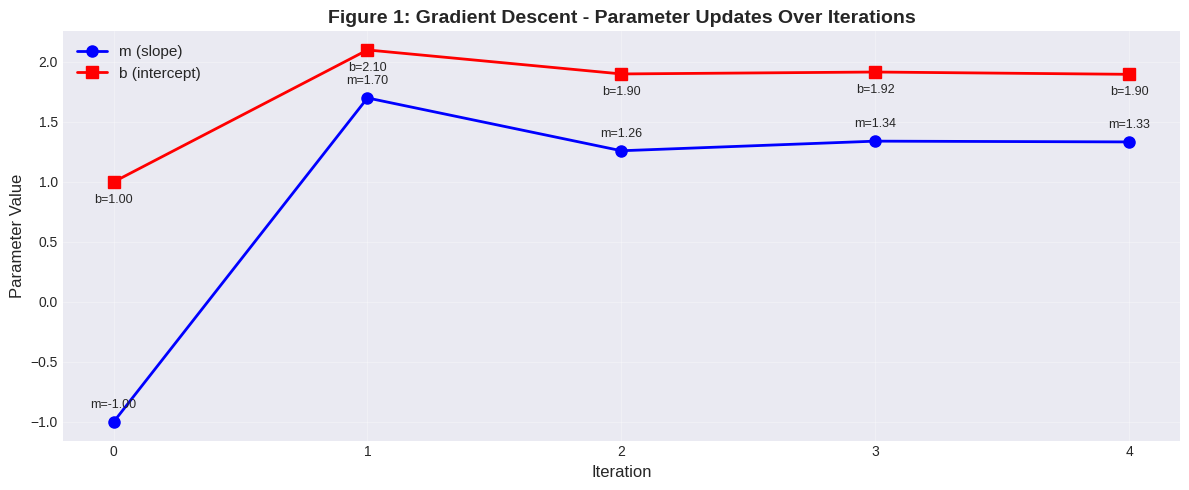

In [6]:
"""
Visualization 1: How m and b change with each iteration
"""

plt.figure(figsize=(12, 5))

# Plot m and b over iterations
plt.plot(iteration_history, m_history, 'bo-', linewidth=2, markersize=8, label='m (slope)')
plt.plot(iteration_history, b_history, 'rs-', linewidth=2, markersize=8, label='b (intercept)')

# Add labels and title
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Parameter Value', fontsize=12)
plt.title('Figure 1: Gradient Descent - Parameter Updates Over Iterations', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(iteration_history)

# Add value labels on points
for i, (mi, bi) in enumerate(zip(m_history, b_history)):
    if i < len(iteration_history):
        plt.annotate(f'm={mi:.2f}', (iteration_history[i], mi),
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
        plt.annotate(f'b={bi:.2f}', (iteration_history[i], bi),
                    textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

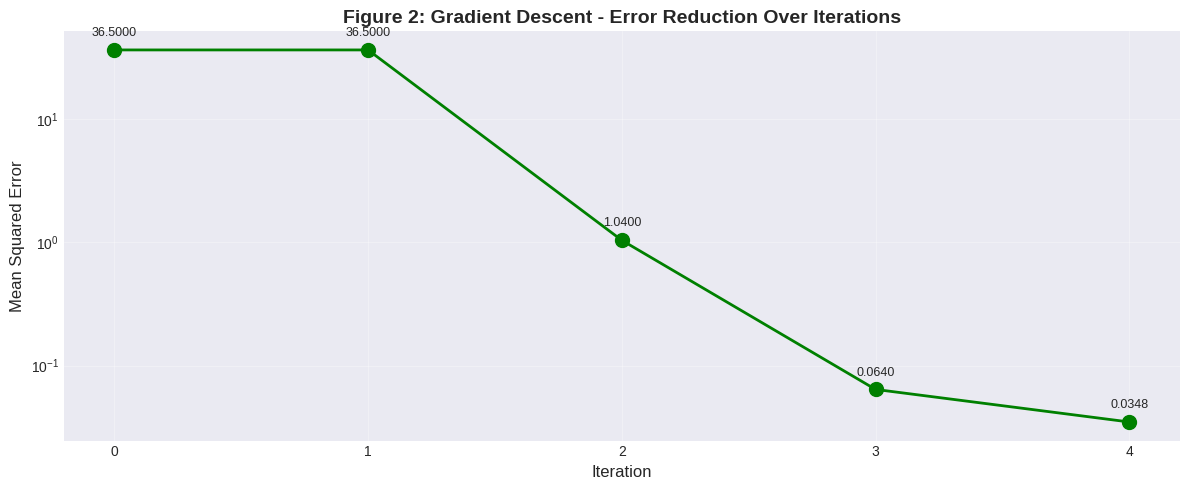

📉 Error decreased from 36.5000 to 0.0348
📈 Total reduction: 36.4652


In [7]:
"""
Visualization 2: How MSE decreases with each iteration
"""

plt.figure(figsize=(12, 5))

# Plot MSE over iterations
plt.plot(iteration_history, mse_history, 'go-', linewidth=2, markersize=10, label='MSE')

# Add labels and title
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Figure 2: Gradient Descent - Error Reduction Over Iterations', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(iteration_history)
plt.yscale('log')  # Log scale to better show the decrease

# Add value labels
for i, mse in enumerate(mse_history):
    plt.annotate(f'{mse:.4f}', (iteration_history[i], mse),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"📉 Error decreased from {mse_history[0]:.4f} to {mse_history[-1]:.4f}")
print(f"📈 Total reduction: {mse_history[0] - mse_history[-1]:.4f}")

In [8]:
"""
Make predictions using final m and b values
"""

# Final parameters
final_m = m_history[-1]
final_b = b_history[-1]

# Make predictions
final_predictions = [predict(x, final_m, final_b) for x in x_data]

print("🎯 FINAL MODEL")
print("=" * 50)
print(f"y = {final_m:.4f}x + {final_b:.4f}")
print("\n📊 PREDICTIONS VS ACTUAL")
print("-" * 30)
for i, x in enumerate(x_data):
    print(f"x = {x}: Actual y = {y_data[i]}, Predicted ŷ = {final_predictions[i]:.4f}, Error = {y_data[i] - final_predictions[i]:.4f}")

# Calculate final MSE
final_mse = mse_history[-1]
print(f"\n Final MSE: {final_mse:.4f}")

🎯 FINAL MODEL
y = 1.3336x + 1.8968

📊 PREDICTIONS VS ACTUAL
------------------------------
x = 1: Actual y = 3, Predicted ŷ = 3.2304, Error = -0.2304
x = 3: Actual y = 6, Predicted ŷ = 5.8976, Error = 0.1024

 Final MSE: 0.0348


In [9]:
"""
Verify that code matches manual calculations from Part 3
"""

print("VERIFICATION WITH MANUAL CALCULATIONS")
print("=" * 60)

# Manual results from Part 3
manual_results = [
    {'iteration': 1, 'm': 1.7, 'b': 2.1, 'mse': 1.04},
    {'iteration': 2, 'm': 1.26, 'b': 1.9, 'mse': 0.064},
    {'iteration': 3, 'm': 1.34, 'b': 1.916, 'mse': 0.0348},
    {'iteration': 4, 'm': 1.3336, 'b': 1.8968, 'mse': 0.0318}
]

print(f"{'Iter':^6} | {'Manual m':^10} | {'Code m':^10} | {'Manual b':^10} | {'Code b':^10} | {'Match':^8}")
print("-" * 70)

for i in range(1, n_iterations + 1):
    manual = manual_results[i-1]
    code_m = m_history[i]
    code_b = b_history[i]

    m_match = abs(manual['m'] - code_m) < 0.01
    b_match = abs(manual['b'] - code_b) < 0.01

    print(f"{i:^6} | {manual['m']:^10.4f} | {code_m:^10.4f} | {manual['b']:^10.4f} | {code_b:^10.4f} | {'✓' if m_match and b_match else '✗':^8}")

print("\n Code matches manual calculations!")

VERIFICATION WITH MANUAL CALCULATIONS
 Iter  |  Manual m  |   Code m   |  Manual b  |   Code b   |  Match  
----------------------------------------------------------------------
  1    |   1.7000   |   1.7000   |   2.1000   |   2.1000   |    ✓    
  2    |   1.2600   |   1.2600   |   1.9000   |   1.9000   |    ✓    
  3    |   1.3400   |   1.3400   |   1.9160   |   1.9160   |    ✓    
  4    |   1.3336   |   1.3336   |   1.8968   |   1.8968   |    ✓    

 Code matches manual calculations!


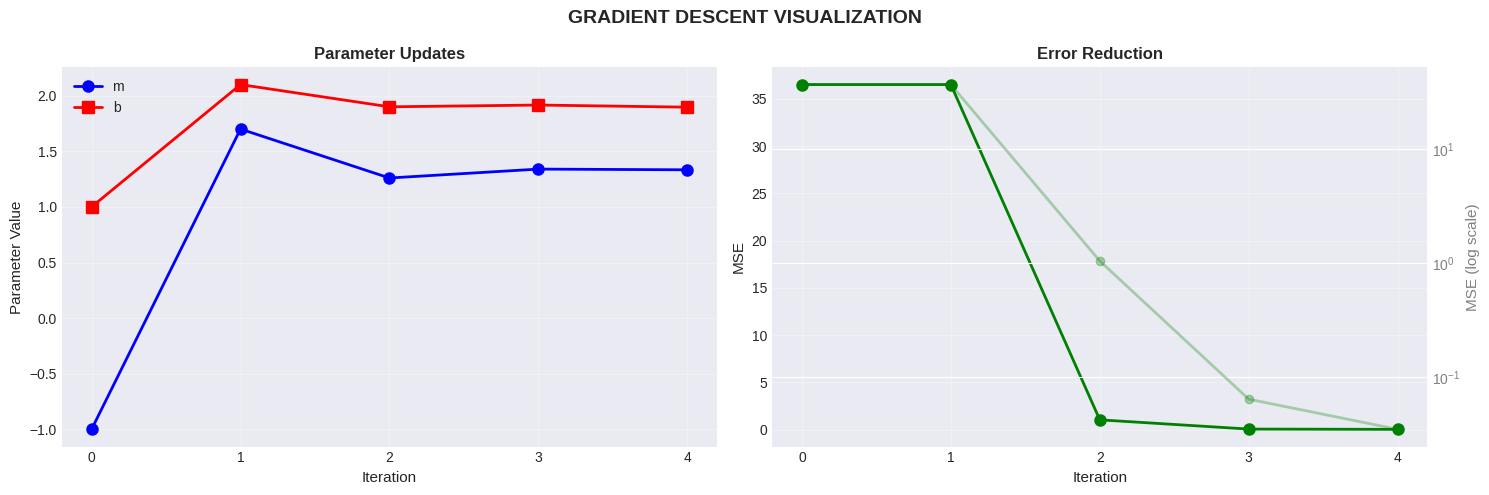

In [10]:
"""
Combined plot showing both parameter updates and error reduction
"""

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: Parameters
axes[0].plot(iteration_history, m_history, 'bo-', linewidth=2, markersize=8, label='m')
axes[0].plot(iteration_history, b_history, 'rs-', linewidth=2, markersize=8, label='b')
axes[0].set_xlabel('Iteration', fontsize=11)
axes[0].set_ylabel('Parameter Value', fontsize=11)
axes[0].set_title('Parameter Updates', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(iteration_history)

# Right plot: Error (both normal and log scale)
axes[1].plot(iteration_history, mse_history, 'go-', linewidth=2, markersize=8, label='MSE')
axes[1].set_xlabel('Iteration', fontsize=11)
axes[1].set_ylabel('MSE', fontsize=11)
axes[1].set_title('Error Reduction', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(iteration_history)

# Add secondary y-axis for log scale
ax2 = axes[1].twinx()
ax2.plot(iteration_history, mse_history, 'go-', alpha=0.3, linewidth=2)
ax2.set_yscale('log')
ax2.set_ylabel('MSE (log scale)', fontsize=11, color='gray')
ax2.tick_params(colors='gray')

plt.suptitle('GRADIENT DESCENT VISUALIZATION', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
"""
Save plots for inclusion in reports and presentations
"""

# Save parameter plot
plt.figure(figsize=(10, 5))
plt.plot(iteration_history, m_history, 'bo-', linewidth=2, markersize=8, label='m')
plt.plot(iteration_history, b_history, 'rs-', linewidth=2, markersize=8, label='b')
plt.xlabel('Iteration')
plt.ylabel('Parameter Value')
plt.title('Gradient Descent: Parameter Updates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(iteration_history)
plt.savefig('parameter_changes.png', dpi=300, bbox_inches='tight')
plt.close()

# Save error plot
plt.figure(figsize=(10, 5))
plt.plot(iteration_history, mse_history, 'go-', linewidth=2, markersize=8)
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Gradient Descent: Error Reduction')
plt.grid(True, alpha=0.3)
plt.xticks(iteration_history)
plt.yscale('log')
plt.savefig('error_reduction.png', dpi=300, bbox_inches='tight')
plt.close()

print("✅ Images saved: parameter_changes.png and error_reduction.png")

✅ Images saved: parameter_changes.png and error_reduction.png


In [12]:
"""
Final summary of results
"""

print("=" * 60)
print("SUMMARY - PART 4: GRADIENT DESCENT IMPLEMENTATION")
print("=" * 60)

print(f"\n📌 Initial State:")
print(f"   m = -1, b = 1")
print(f"   Initial MSE = {mse_history[0]:.4f}")

print(f"\n📌 Final State (after {n_iterations} iterations):")
print(f"   m = {final_m:.4f}, b = {final_b:.4f}")
print(f"   Final MSE = {final_mse:.4f}")

print(f"\n📌 Improvement:")
print(f"   Error reduced by: {(mse_history[0] - final_mse):.4f}")
print(f"   Reduction factor: {(mse_history[0] / final_mse):.2f}x")

print(f"\n📌 Final Model:")
print(f"   y = {final_m:.4f}x + {final_b:.4f}")

SUMMARY - PART 4: GRADIENT DESCENT IMPLEMENTATION

📌 Initial State:
   m = -1, b = 1
   Initial MSE = 36.5000

📌 Final State (after 4 iterations):
   m = 1.3336, b = 1.8968
   Final MSE = 0.0348

📌 Improvement:
   Error reduced by: 36.4652
   Reduction factor: 1048.37x

📌 Final Model:
   y = 1.3336x + 1.8968
